In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense

In [2]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"

dataframe = pd.read_csv(
    url,
    usecols=[1]
)

print(dataframe.head())
print()
print("Dataset shape:", dataframe.shape)

   Passengers
0         112
1         118
2         132
3         129
4         121

Dataset shape: (144, 1)


In [3]:
dataset = dataframe.values

dataset = dataset.astype("float32")

print("Dataset shape:", dataset.shape)
print("First 10 values:")
print(dataset[:10])

Dataset shape: (144, 1)
First 10 values:
[[112.]
 [118.]
 [132.]
 [129.]
 [121.]
 [135.]
 [148.]
 [148.]
 [136.]
 [119.]]


In [4]:
scaler = MinMaxScaler(
    feature_range=(0, 1)
)

dataset = scaler.fit_transform(dataset)

print("First 10 normalized values:")
print(dataset[:10])

First 10 normalized values:
[[0.01544401]
 [0.02702703]
 [0.05405405]
 [0.04826255]
 [0.03281853]
 [0.05984557]
 [0.08494207]
 [0.08494207]
 [0.06177607]
 [0.02895753]]


In [5]:
def create_dataset(dataset, look_back=1):

    dataX = []
    dataY = []

    for i in range(len(dataset) - look_back - 1):

        a = dataset[
            i:(i + look_back),
            0
        ]

        dataX.append(a)

        dataY.append(
            dataset[i + look_back, 0]
        )

    return np.array(dataX), np.array(dataY)

In [6]:
look_back = 10

X, Y = create_dataset(
    dataset,
    look_back
)

print("X shape:", X.shape)
print("Y shape:", Y.shape)

X shape: (133, 10)
Y shape: (133,)


In [7]:
print("First input sequence:")
print(X[0])

print("\nFirst target:")
print(Y[0])

First input sequence:
[0.01544401 0.02702703 0.05405405 0.04826255 0.03281853 0.05984557
 0.08494207 0.08494207 0.06177607 0.02895753]

First target:
0.0


In [8]:
X = np.reshape(
    X,
    (
        X.shape[0],
        X.shape[1],
        1
    )
)

print("Reshaped X:", X.shape)
print("Y shape:", Y.shape)

Reshaped X: (133, 10, 1)
Y shape: (133,)


In [10]:
import tensorflow as tf
with tf.device("/GPU:0"):

    model = Sequential([
        
        GRU(
            units=4,
            return_sequences=True,
            input_shape=(look_back, 1)
        ),

        GRU(
            units=4
        ),

        Dense(
            units=1
        )
    ])

model.compile(
    optimizer="adam",
    loss="mean_squared_error"
)

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 gru (GRU)                   (None, 10, 4)             84        
                                                                 
 gru_1 (GRU)                 (None, 4)                 120       
                                                                 
 dense (Dense)               (None, 1)                 5         
                                                                 
Total params: 209
Trainable params: 209
Non-trainable params: 0
_________________________________________________________________


In [11]:
history = model.fit(
    X,
    Y,
    epochs=100,
    batch_size=1,
    verbose=2
)

Epoch 1/100
133/133 - 6s - loss: 0.1142 - 6s/epoch - 48ms/step
Epoch 2/100
133/133 - 1s - loss: 0.0495 - 829ms/epoch - 6ms/step
Epoch 3/100
133/133 - 1s - loss: 0.0323 - 851ms/epoch - 6ms/step
Epoch 4/100
133/133 - 1s - loss: 0.0193 - 817ms/epoch - 6ms/step
Epoch 5/100
133/133 - 1s - loss: 0.0111 - 837ms/epoch - 6ms/step
Epoch 6/100
133/133 - 1s - loss: 0.0104 - 819ms/epoch - 6ms/step
Epoch 7/100
133/133 - 1s - loss: 0.0107 - 813ms/epoch - 6ms/step
Epoch 8/100
133/133 - 1s - loss: 0.0107 - 832ms/epoch - 6ms/step
Epoch 9/100
133/133 - 1s - loss: 0.0099 - 776ms/epoch - 6ms/step
Epoch 10/100
133/133 - 1s - loss: 0.0095 - 832ms/epoch - 6ms/step
Epoch 11/100
133/133 - 1s - loss: 0.0097 - 781ms/epoch - 6ms/step
Epoch 12/100
133/133 - 1s - loss: 0.0089 - 817ms/epoch - 6ms/step
Epoch 13/100
133/133 - 1s - loss: 0.0087 - 813ms/epoch - 6ms/step
Epoch 14/100
133/133 - 1s - loss: 0.0090 - 837ms/epoch - 6ms/step
Epoch 15/100
133/133 - 1s - loss: 0.0086 - 889ms/epoch - 7ms/step
Epoch 16/100
133/133 

In [12]:
train_predict = model.predict(
    X,
    verbose=0
)

print("Prediction shape:", train_predict.shape)
print()
print("First 5 predictions:")
print(train_predict[:5])

Prediction shape: (133, 1)

First 5 predictions:
[[ 0.00956237]
 [-0.01734687]
 [-0.0005402 ]
 [-0.00658775]
 [ 0.01107052]]


In [13]:
train_predict = scaler.inverse_transform(
    train_predict
)

print("First 5 predictions in original scale:")
print(train_predict[:5])

First 5 predictions in original scale:
[[108.95331]
 [ 95.01433]
 [103.72018]
 [100.58755]
 [109.73453]]


In [14]:
Y_actual = scaler.inverse_transform(
    Y.reshape(-1, 1)
)

print("First 5 actual passenger counts:")
print(Y_actual[:5])

First 5 actual passenger counts:
[[104.]
 [118.]
 [115.]
 [126.]
 [141.]]


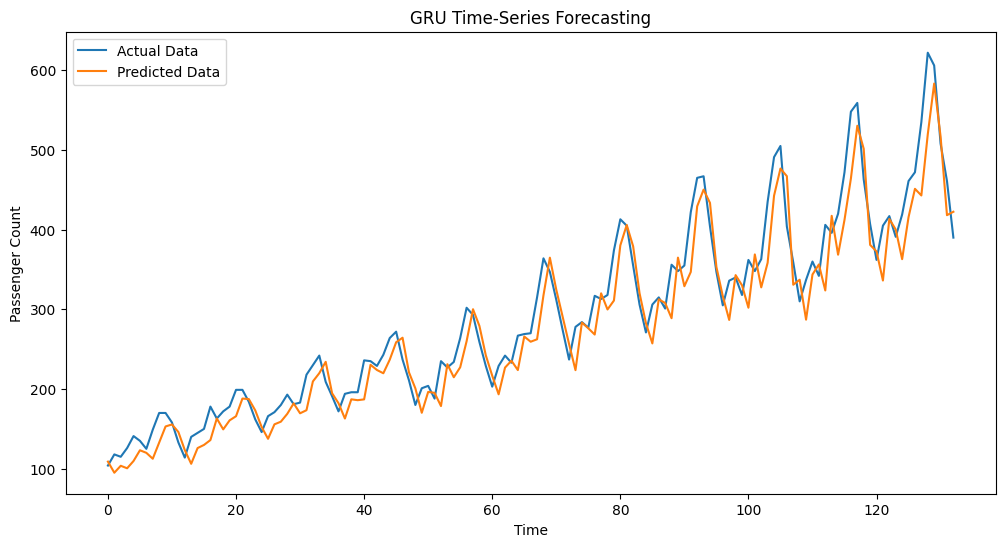

In [15]:
plt.figure(figsize=(12, 6))

plt.plot(
    Y_actual[:, 0],
    label="Actual Data"
)

plt.plot(
    train_predict[:, 0],
    label="Predicted Data"
)

plt.title("GRU Time-Series Forecasting")
plt.xlabel("Time")
plt.ylabel("Passenger Count")

plt.legend()
plt.show()